In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import ast
import os

# Load candidates from Phase 4
df = pd.read_csv("results/fh_rflp_candidates.csv")
print(f"Loaded {len(df)} RFLP candidates")

# Create figures folder
os.makedirs("results/figures", exist_ok=True)
print("figures folder ready")

Loaded 23 RFLP candidates
figures folder ready


In [2]:
def draw_gel(samples, title, filename, 
             ladder=[100,200,300,400,500,600,800,1000]):
    """
    Simulate an agarose gel electrophoresis image.
    
    samples: list of dicts with keys:
        - label:     lane label (e.g. "WT", "Mutant", "Het")
        - fragments: list of fragment sizes in bp
        - color:     band color
    """
    
    # Page setup
    n_lanes = len(samples) + 1  # +1 for ladder
    fig, ax = plt.subplots(figsize=(2 + n_lanes * 1.4, 7))
    ax.set_facecolor("#111827")
    fig.patch.set_facecolor("#111827")
    
    def bp_to_y(bp, y_min=0.08, y_max=0.92,
                ref_min=80, ref_max=1200):
        """Convert fragment size to gel Y position (log scale)."""
        log_bp  = np.log10(np.clip(bp, ref_min, ref_max))
        log_min = np.log10(ref_min)
        log_max = np.log10(ref_max)
        # Invert: larger fragments stay near top (wells)
        return y_max - (log_bp - log_min) / (log_max - log_min) * (y_max - y_min)
    
    lane_w   = 0.55
    spacing  = 1.0
    
    # Build lane list: ladder first, then samples
    all_lanes = (
        [{"label": "Ladder", "fragments": ladder, 
          "color": "#9ca3af", "is_ladder": True}] +
        [dict(s, is_ladder=False) for s in samples]
    )
    
    for i, lane in enumerate(all_lanes):
        x = i * spacing
        color = lane.get("color", "#22d3ee")
        
        for bp in lane["fragments"]:
            y = bp_to_y(bp)
            h = 0.013
            
            # Larger fragments = slightly brighter (more DNA mass)
            alpha = 0.45 + 0.55 * min(bp / 600, 1.0)
            
            # Draw band as rounded rectangle
            fancy = mpatches.FancyBboxPatch(
                (x - lane_w/2, y - h/2),
                lane_w, h,
                boxstyle="round,pad=0.003",
                facecolor=color,
                edgecolor="none",
                alpha=alpha
            )
            ax.add_patch(fancy)
            
            # Size labels on ladder and small fragment sets
            if lane["is_ladder"] or len(lane["fragments"]) <= 4:
                ax.text(x + lane_w/2 + 0.08, y,
                        f"{bp} bp",
                        va="center", ha="left",
                        fontsize=6.5, color="#d1d5db",
                        fontfamily="monospace")
    
    # Lane labels at bottom
    for i, lane in enumerate(all_lanes):
        ax.text(i * spacing, -0.04,
                lane["label"],
                ha="center", va="top",
                fontsize=9, color="white",
                fontweight="bold")
    
    # Wells at top
    for i in range(len(all_lanes)):
        x = i * spacing
        well = mpatches.FancyBboxPatch(
            (x - lane_w/2, 0.935),
            lane_w, 0.03,
            boxstyle="round,pad=0.002",
            facecolor="#374151",
            edgecolor="#6b7280",
            linewidth=0.5
        )
        ax.add_patch(well)
    
    # Title
    ax.set_title(title, color="white", fontsize=11,
                 fontweight="bold", pad=10)
    
    ax.set_xlim(-0.7, (len(all_lanes)-1) * spacing + 0.9)
    ax.set_ylim(-0.08, 1.0)
    ax.axis("off")
    
    plt.tight_layout()
    plt.savefig(filename, dpi=200,
                bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Saved: {filename}")


print("draw_gel() function ready")

draw_gel() function ready


In [3]:
def parse_frags(frag_string):
    """Safely parse fragment list from saved CSV string."""
    try:
        return ast.literal_eval(frag_string)
    except:
        return []

generated = 0
skipped   = 0

for i, row in df.iterrows():
    wt_frags  = parse_frags(row["wt_frags"])
    mut_frags = parse_frags(row["mut_frags"])
    
    if not wt_frags or not mut_frags:
        print(f"  Skipping {row['cdna_change']} — missing fragment data")
        skipped += 1
        continue
    
    # Heterozygous = both WT and mutant bands visible
    het_frags = sorted(list(set(wt_frags + mut_frags)), reverse=True)
    
    # Build lane definitions
    samples = [
        {"label": "WT",     "fragments": wt_frags,  "color": "#22d3ee"},
        {"label": "Het",    "fragments": het_frags,  "color": "#facc15"},
        {"label": "Mutant", "fragments": mut_frags,  "color": "#f87171"},
    ]
    
    # Clean filename
    cdna_clean = (row["cdna_change"]
                  .replace(":", "_")
                  .replace(">", "-")
                  .replace("/", "_")
                  .replace(" ", "_")
                  .replace("(", "")
                  .replace(")", ""))
    
    filename = f"results/figures/{row['gene']}_{cdna_clean}_{row['best_enzyme']}.png"
    title    = (f"{row['gene']}  {row['cdna_change']}  —  "
                f"{row['best_enzyme']} digest\n"
                f"WT: {wt_frags} bp   |   "
                f"Mutant: {mut_frags} bp   |   "
                f"Diff: {row['frag_diff_bp']} bp")
    
    draw_gel(samples, title, filename)
    generated += 1

print(f"\nGel figures generated: {generated}")
print(f"Skipped:               {skipped}")
print(f"Saved to:              results/figures/")

  Saved: results/figures/LDLR_c.408C-G_EcoT38I.png
  Saved: results/figures/LDLR_c.155G-T_PfoI.png
  Saved: results/figures/LDLR_c.457T-C_GsuI.png
  Saved: results/figures/LDLR_c.1840T-G_Hpy99I.png
  Saved: results/figures/LDLR_c.1054T-G_Eam1104I.png
  Saved: results/figures/LDLR_c.1961T-G_Eam1104I.png
  Saved: results/figures/LDLR_c.1865A-T_EcoRV.png
  Saved: results/figures/LDLR_c.986G-C_BsrDI.png
  Saved: results/figures/LDLR_c.648T-G_GsaI.png
  Saved: results/figures/LDLR_c.398A-G_BsaJI.png
  Saved: results/figures/LDLR_c.483C-G_PaeI.png
  Saved: results/figures/LDLR_c.1067A-G_BshVI.png
  Saved: results/figures/LDLR_NM_000527.5LDLR_c.818-1G-T_BtsIMutI.png
  Saved: results/figures/LDLR_c.1297G-A_Hpy188III.png
  Saved: results/figures/LDLR_c.325T-A_BtrI.png
  Saved: results/figures/LDLR_c.632A-G_AccBSI.png
  Saved: results/figures/LDLR_c.270T-G_BtgZI.png
  Saved: results/figures/LDLR_NM_000527.5LDLR_c.68-2A-C_BstDSI.png
  Saved: results/figures/APOB_c.9721G-T_EcoT38I.png
  Saved: res

results/figures/LDLR_c.408C-G_EcoT38I.png


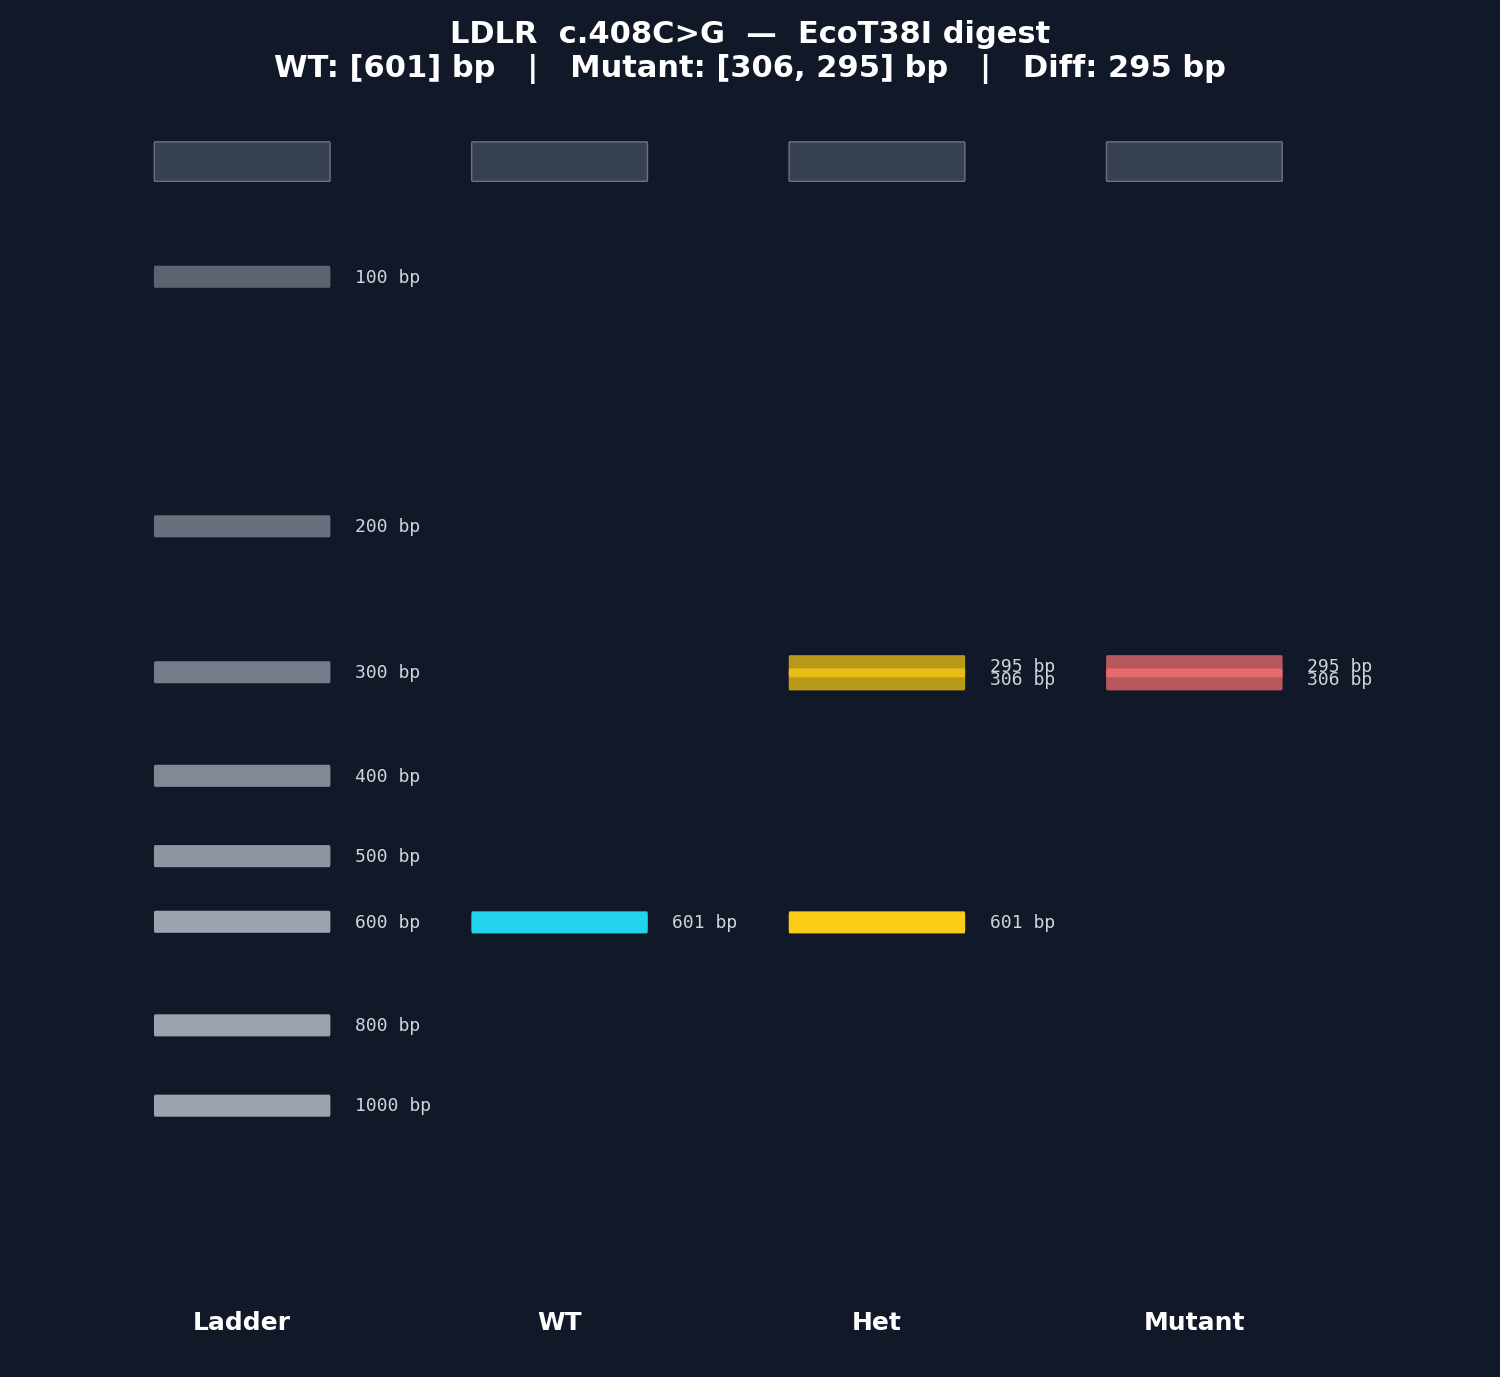

results/figures/LDLR_c.155G-T_PfoI.png


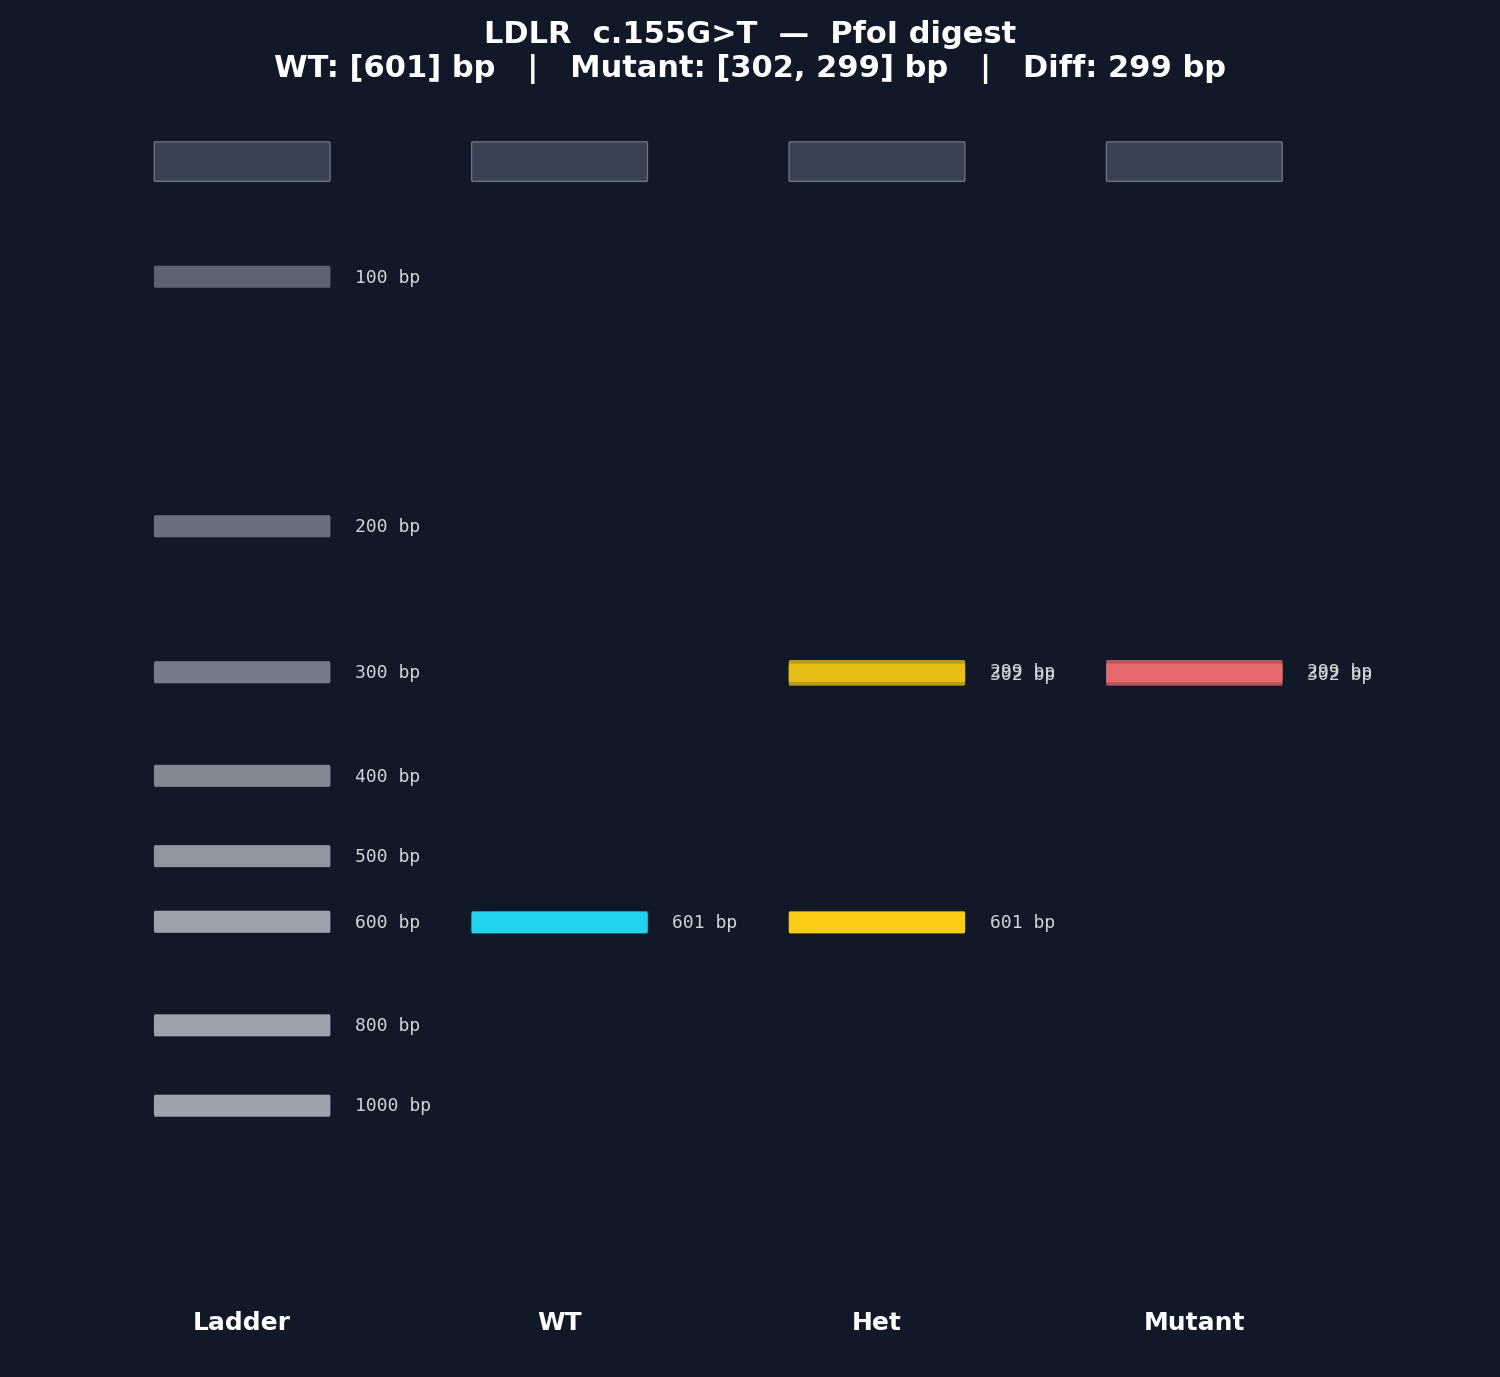

results/figures/APOB_c.9721G-T_EcoT38I.png


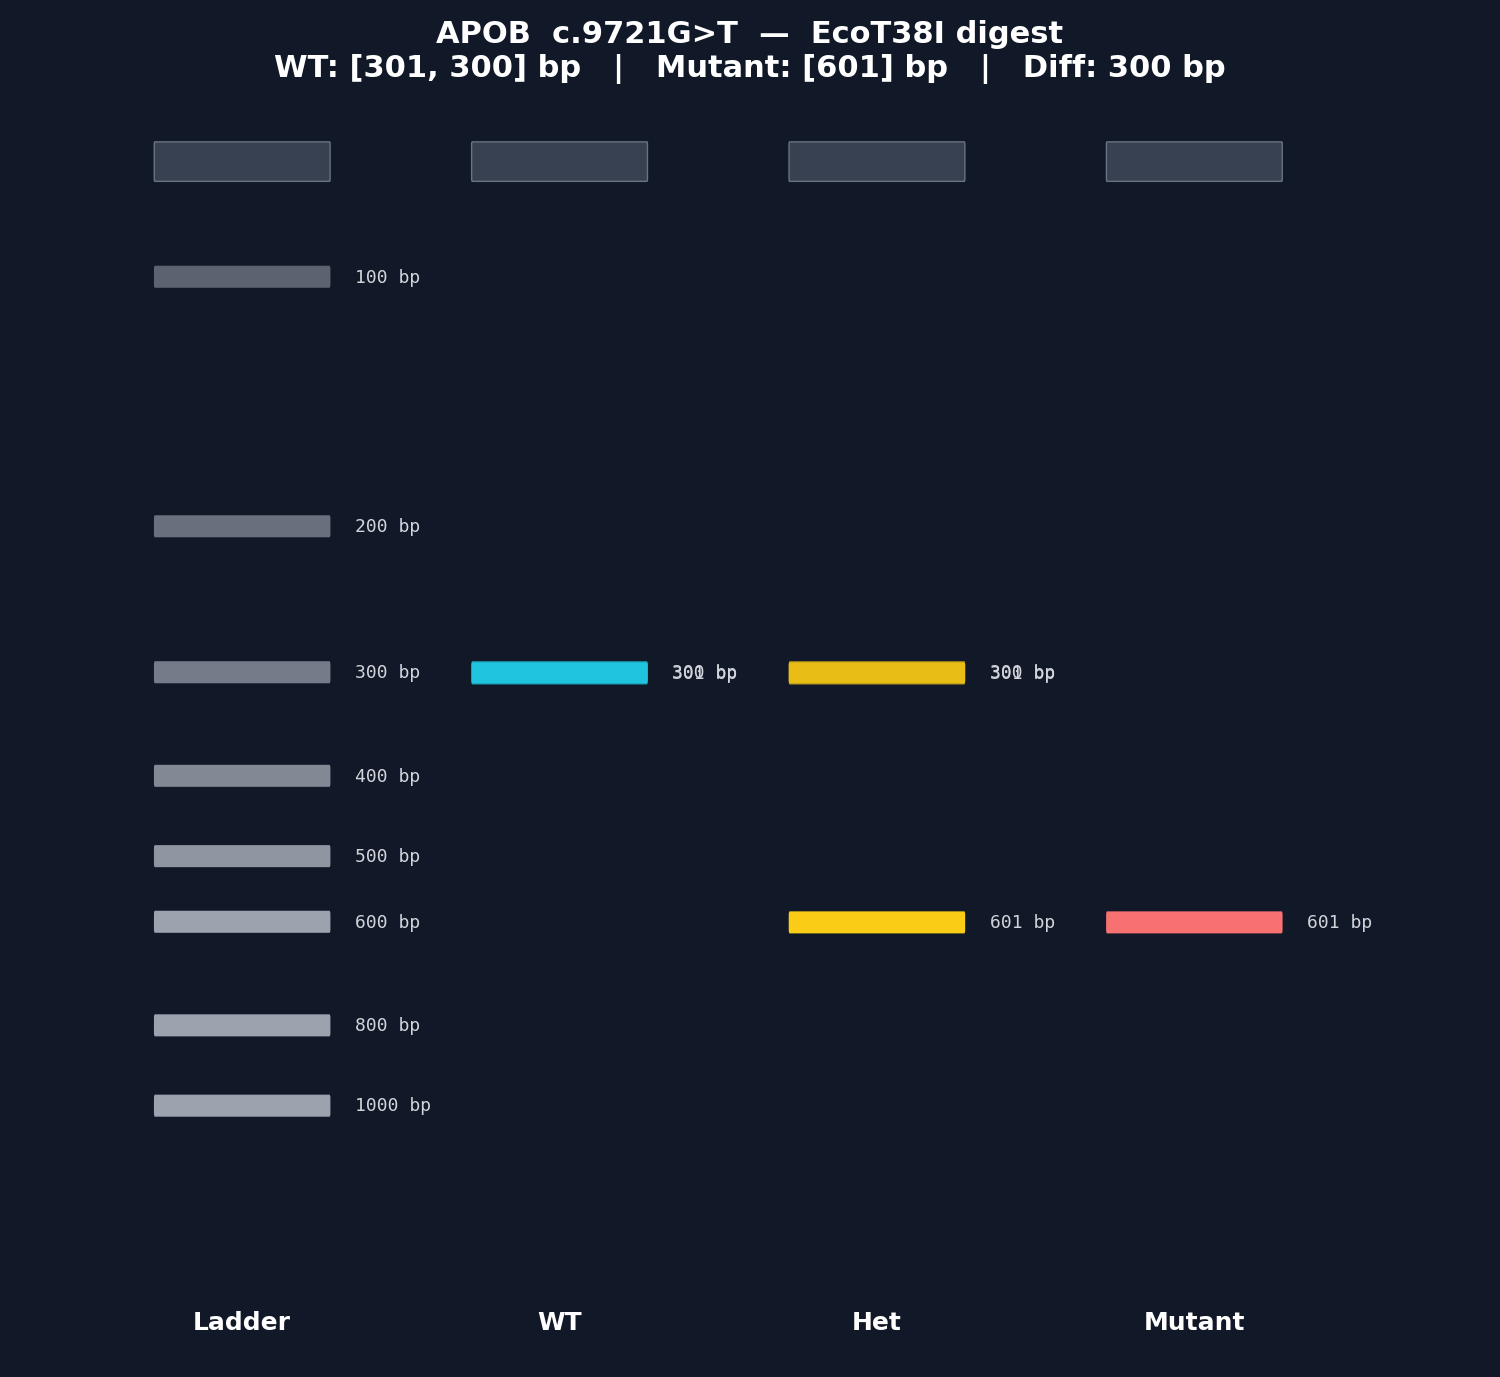

results/figures/APOB_c.11470C-T_MaeI.png


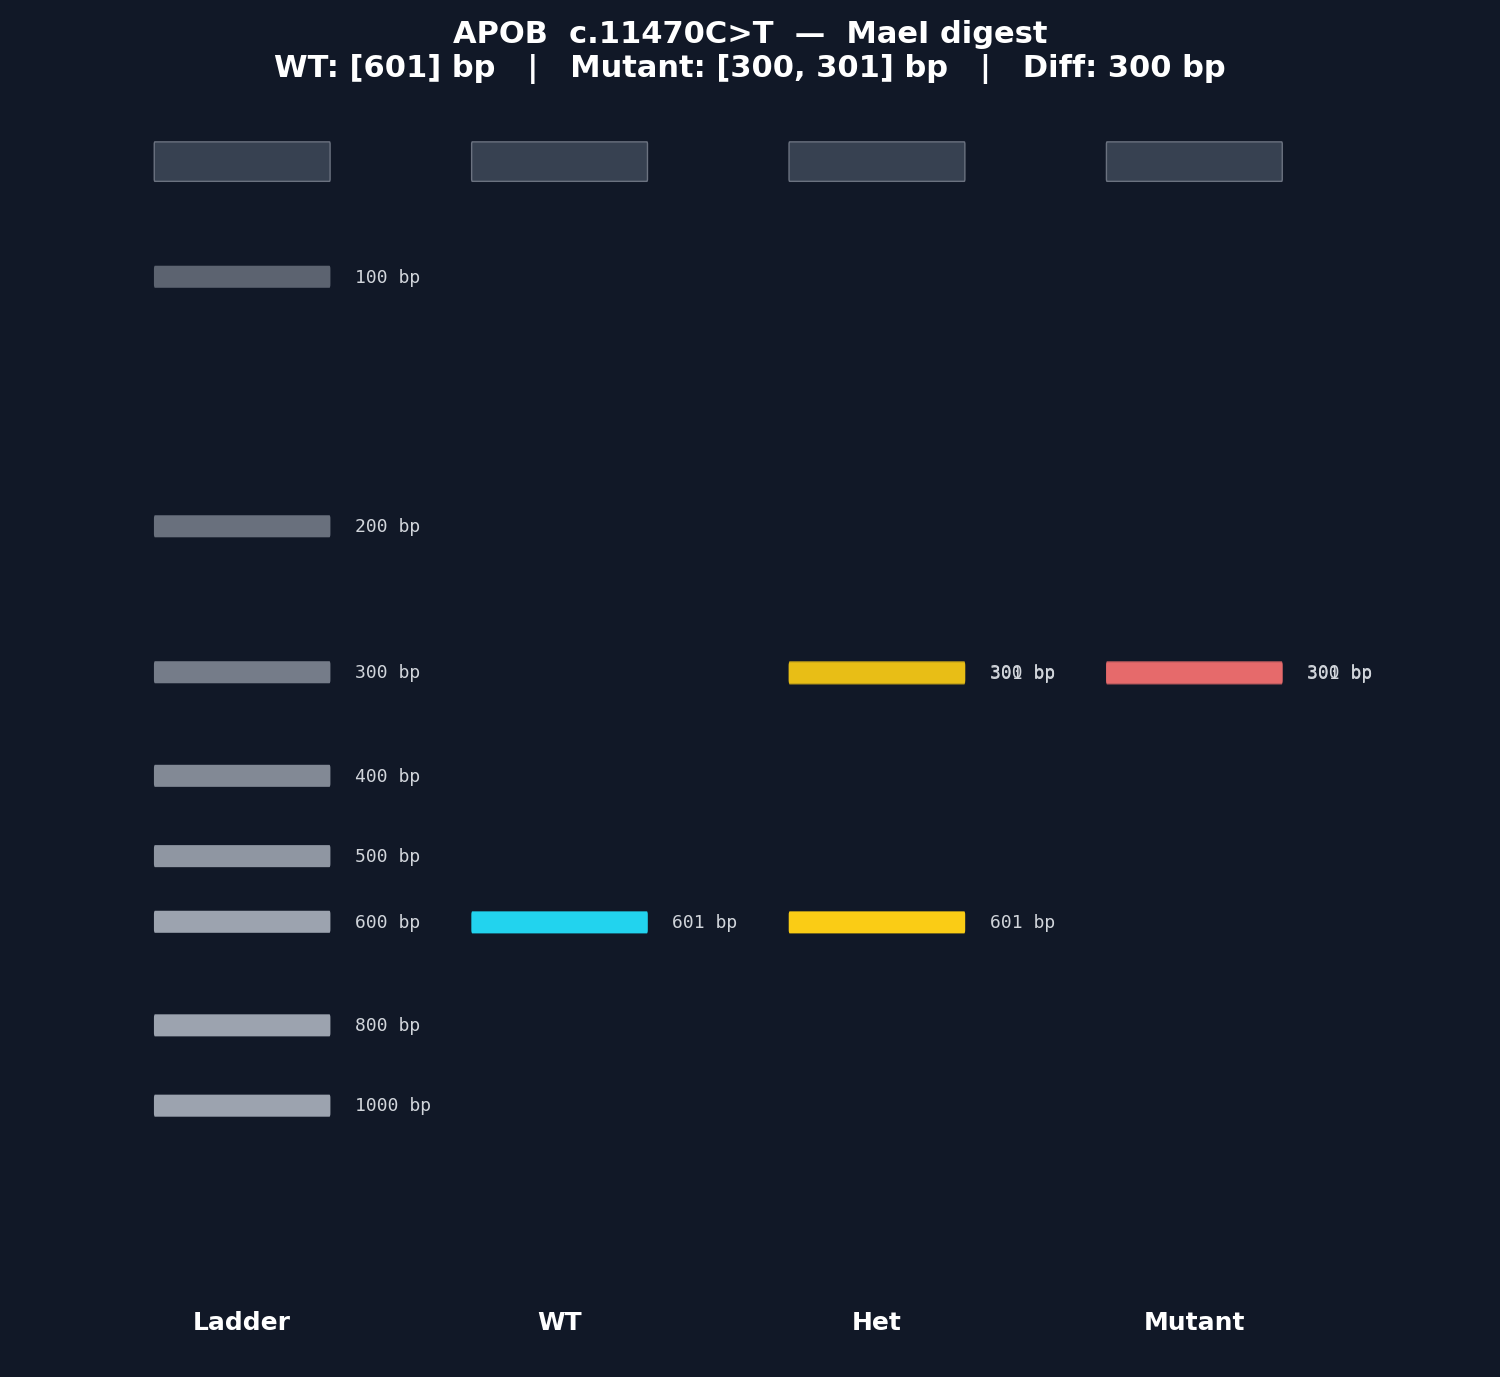

In [4]:
from IPython.display import display, Image

# Display the first 4 gel figures inline
preview_files = [
    f"results/figures/LDLR_c.408C-G_EcoT38I.png",
    f"results/figures/LDLR_c.155G-T_PfoI.png",
    f"results/figures/APOB_c.9721G-T_EcoT38I.png",
    f"results/figures/APOB_c.11470C-T_MaeI.png",
]

for f in preview_files:
    print(f)
    display(Image(filename=f, width=400))

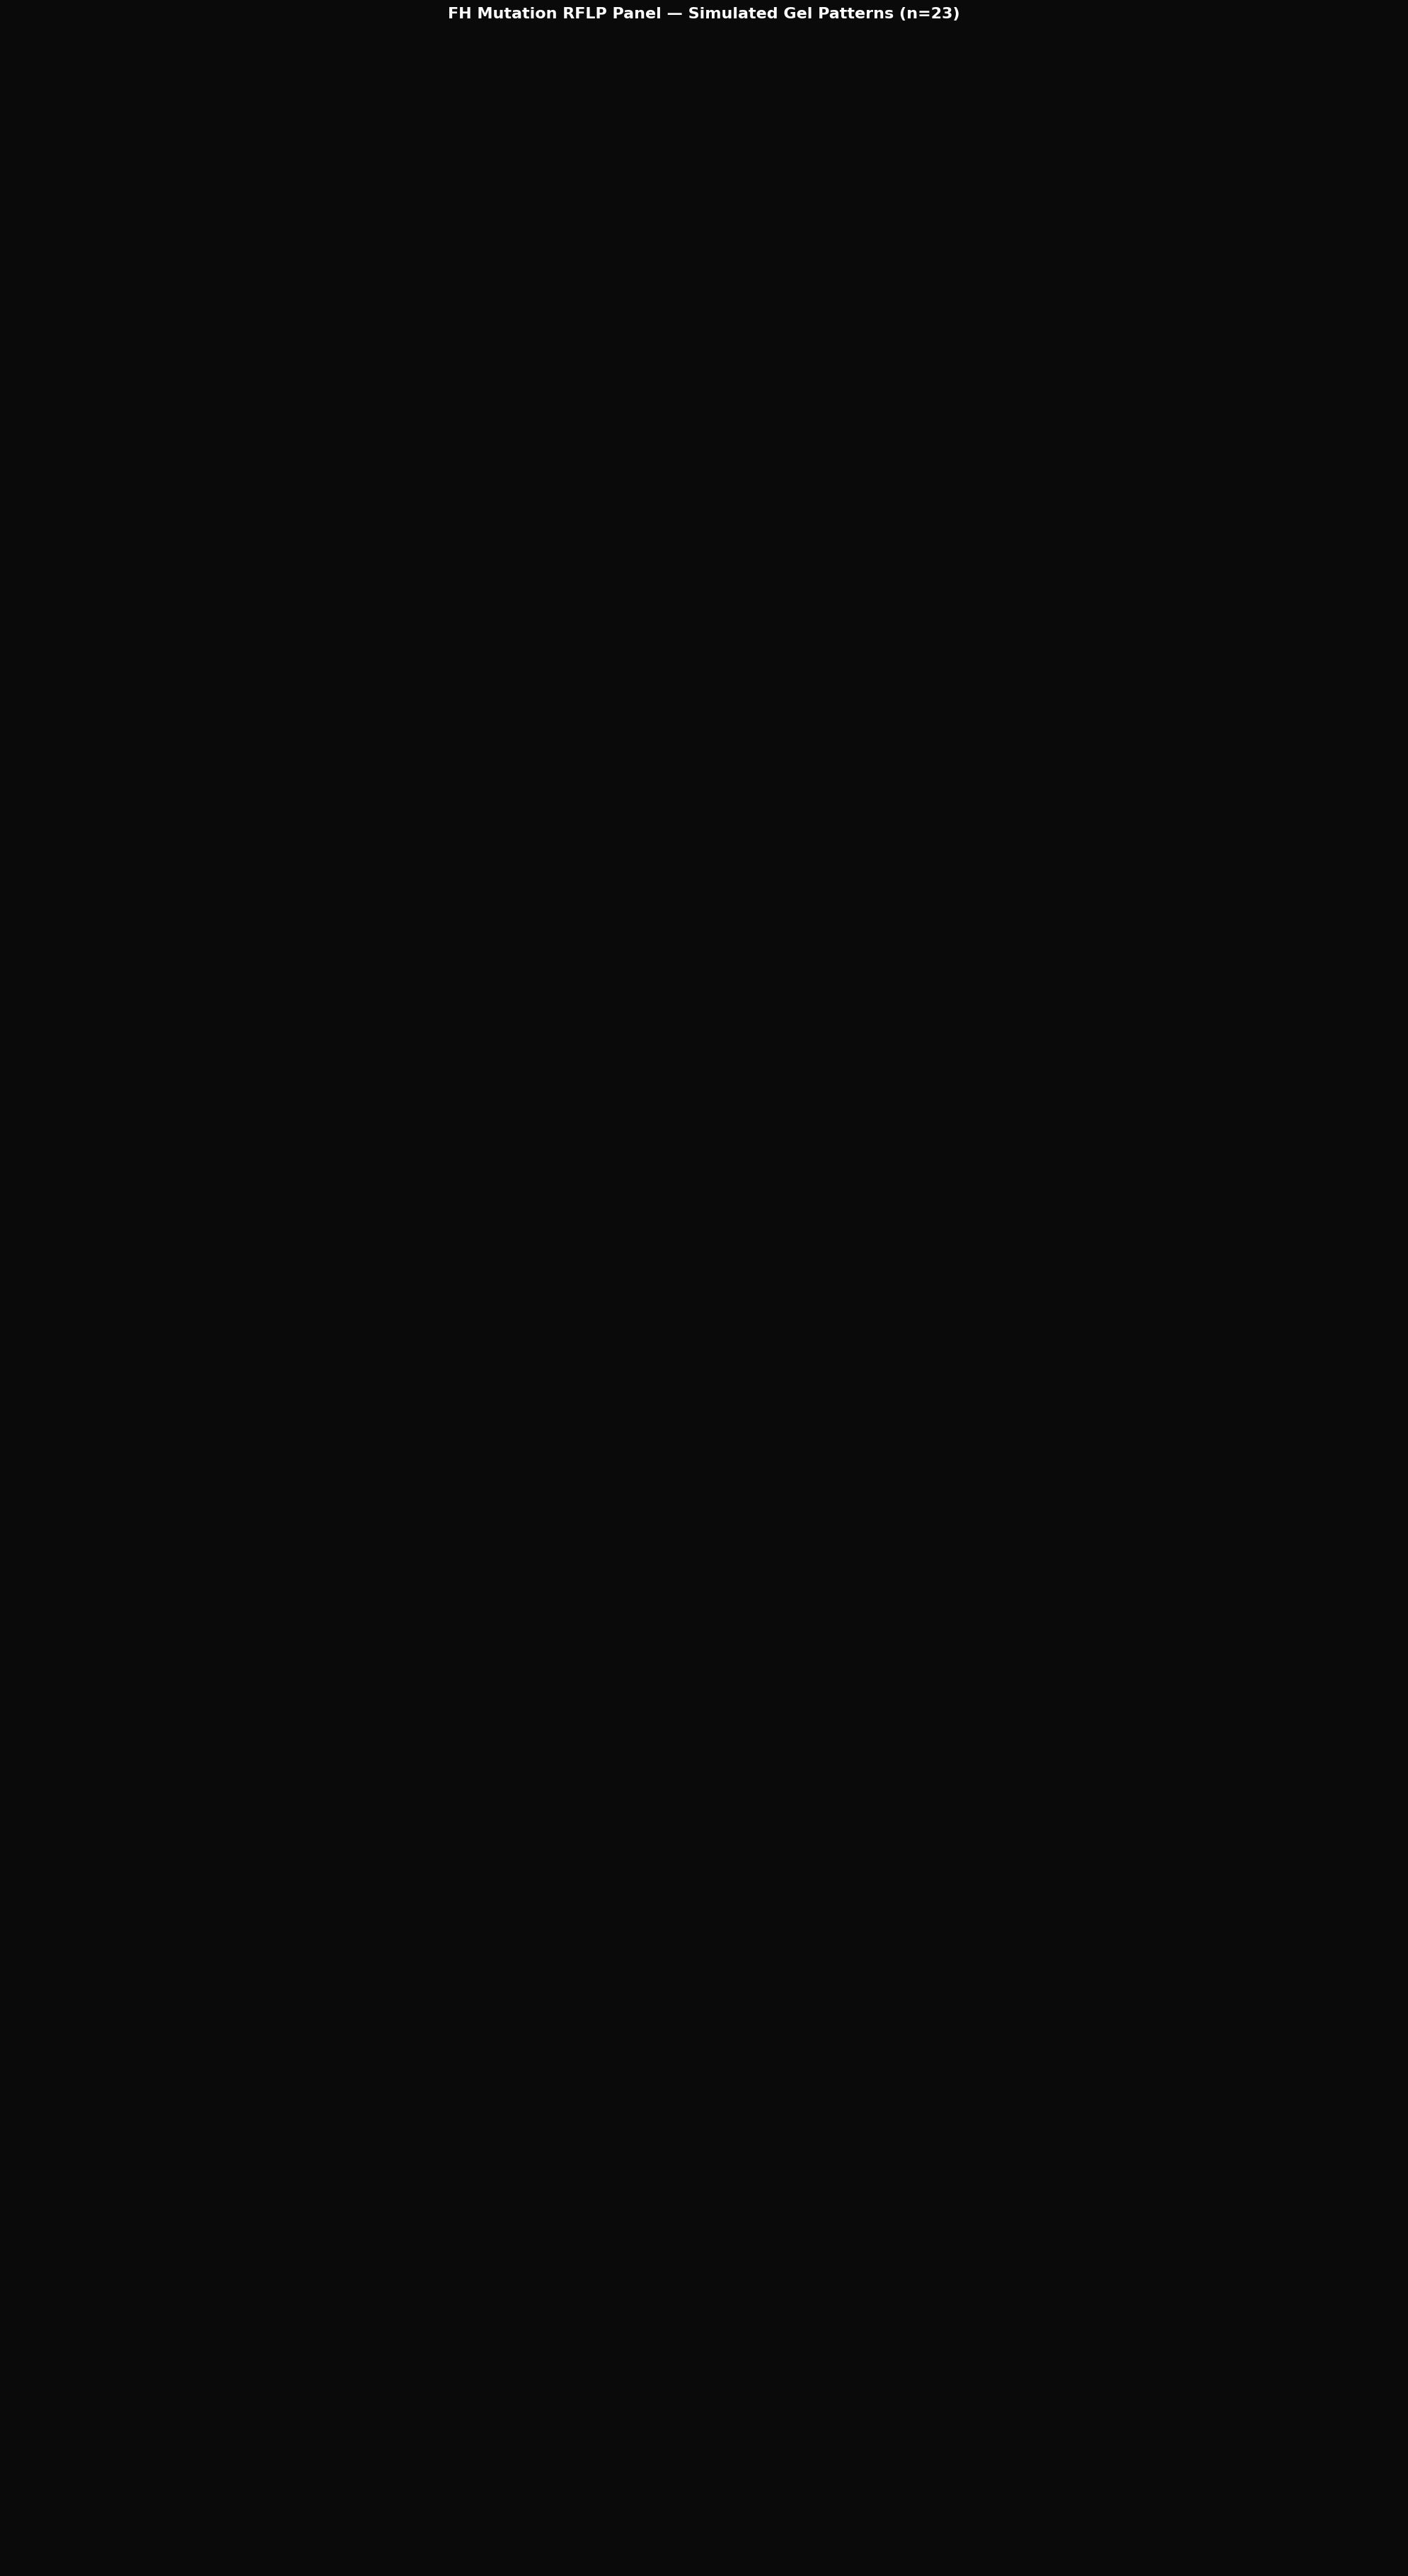

Master panel saved: results/figures/MASTER_gel_panel.png

Phase 5 complete!


In [5]:
import math

files = [f"results/figures/{row['gene']}_{(row['cdna_change'].replace(':','_').replace('>','-').replace('/','_').replace(' ','_').replace('(','').replace(')','' ))}_{row['best_enzyme']}.png" 
         for _, row in df.iterrows()]

# Grid layout
n_cols = 4
n_rows = math.ceil(len(files) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, 
                          figsize=(n_cols * 5, n_rows * 6))
fig.patch.set_facecolor("#0a0a0a")
axes = axes.flatten()

for i, (ax, filepath) in enumerate(zip(axes, files)):
    try:
        img = mpimg.imread(filepath)
        ax.imshow(img)
        ax.axis("off")
    except:
        ax.axis("off")

# Hide any unused subplot slots
for j in range(len(files), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "FH Mutation RFLP Panel — Simulated Gel Patterns (n=23)",
    color="white", fontsize=16, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("results/figures/MASTER_gel_panel.png",
            dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Master panel saved: results/figures/MASTER_gel_panel.png")
print()
print("Phase 5 complete!")

In [6]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Read filenames directly from the folder — no name rebuilding
files = sorted([
    os.path.join("results/figures", f)
    for f in os.listdir("results/figures")
    if f.endswith(".png") and f != "MASTER_gel_panel.png"
])

print(f"Found {len(files)} gel images")
for f in files:
    print(f"  {f}")

Found 23 gel images
  results/figures\APOB_c.11470C-T_MaeI.png
  results/figures\APOB_c.5303C-A_Eam1104I.png
  results/figures\APOB_c.6022G-T_LmnI.png
  results/figures\APOB_c.8602G-T_BstSFI.png
  results/figures\APOB_c.9721G-T_EcoT38I.png
  results/figures\LDLR_NM_000527.5LDLR_c.68-2A-C_BstDSI.png
  results/figures\LDLR_NM_000527.5LDLR_c.818-1G-T_BtsIMutI.png
  results/figures\LDLR_c.1054T-G_Eam1104I.png
  results/figures\LDLR_c.1067A-G_BshVI.png
  results/figures\LDLR_c.1297G-A_Hpy188III.png
  results/figures\LDLR_c.155G-T_PfoI.png
  results/figures\LDLR_c.1840T-G_Hpy99I.png
  results/figures\LDLR_c.1865A-T_EcoRV.png
  results/figures\LDLR_c.1961T-G_Eam1104I.png
  results/figures\LDLR_c.270T-G_BtgZI.png
  results/figures\LDLR_c.325T-A_BtrI.png
  results/figures\LDLR_c.398A-G_BsaJI.png
  results/figures\LDLR_c.408C-G_EcoT38I.png
  results/figures\LDLR_c.457T-C_GsuI.png
  results/figures\LDLR_c.483C-G_PaeI.png
  results/figures\LDLR_c.632A-G_AccBSI.png
  results/figures\LDLR_c.648T-G_G

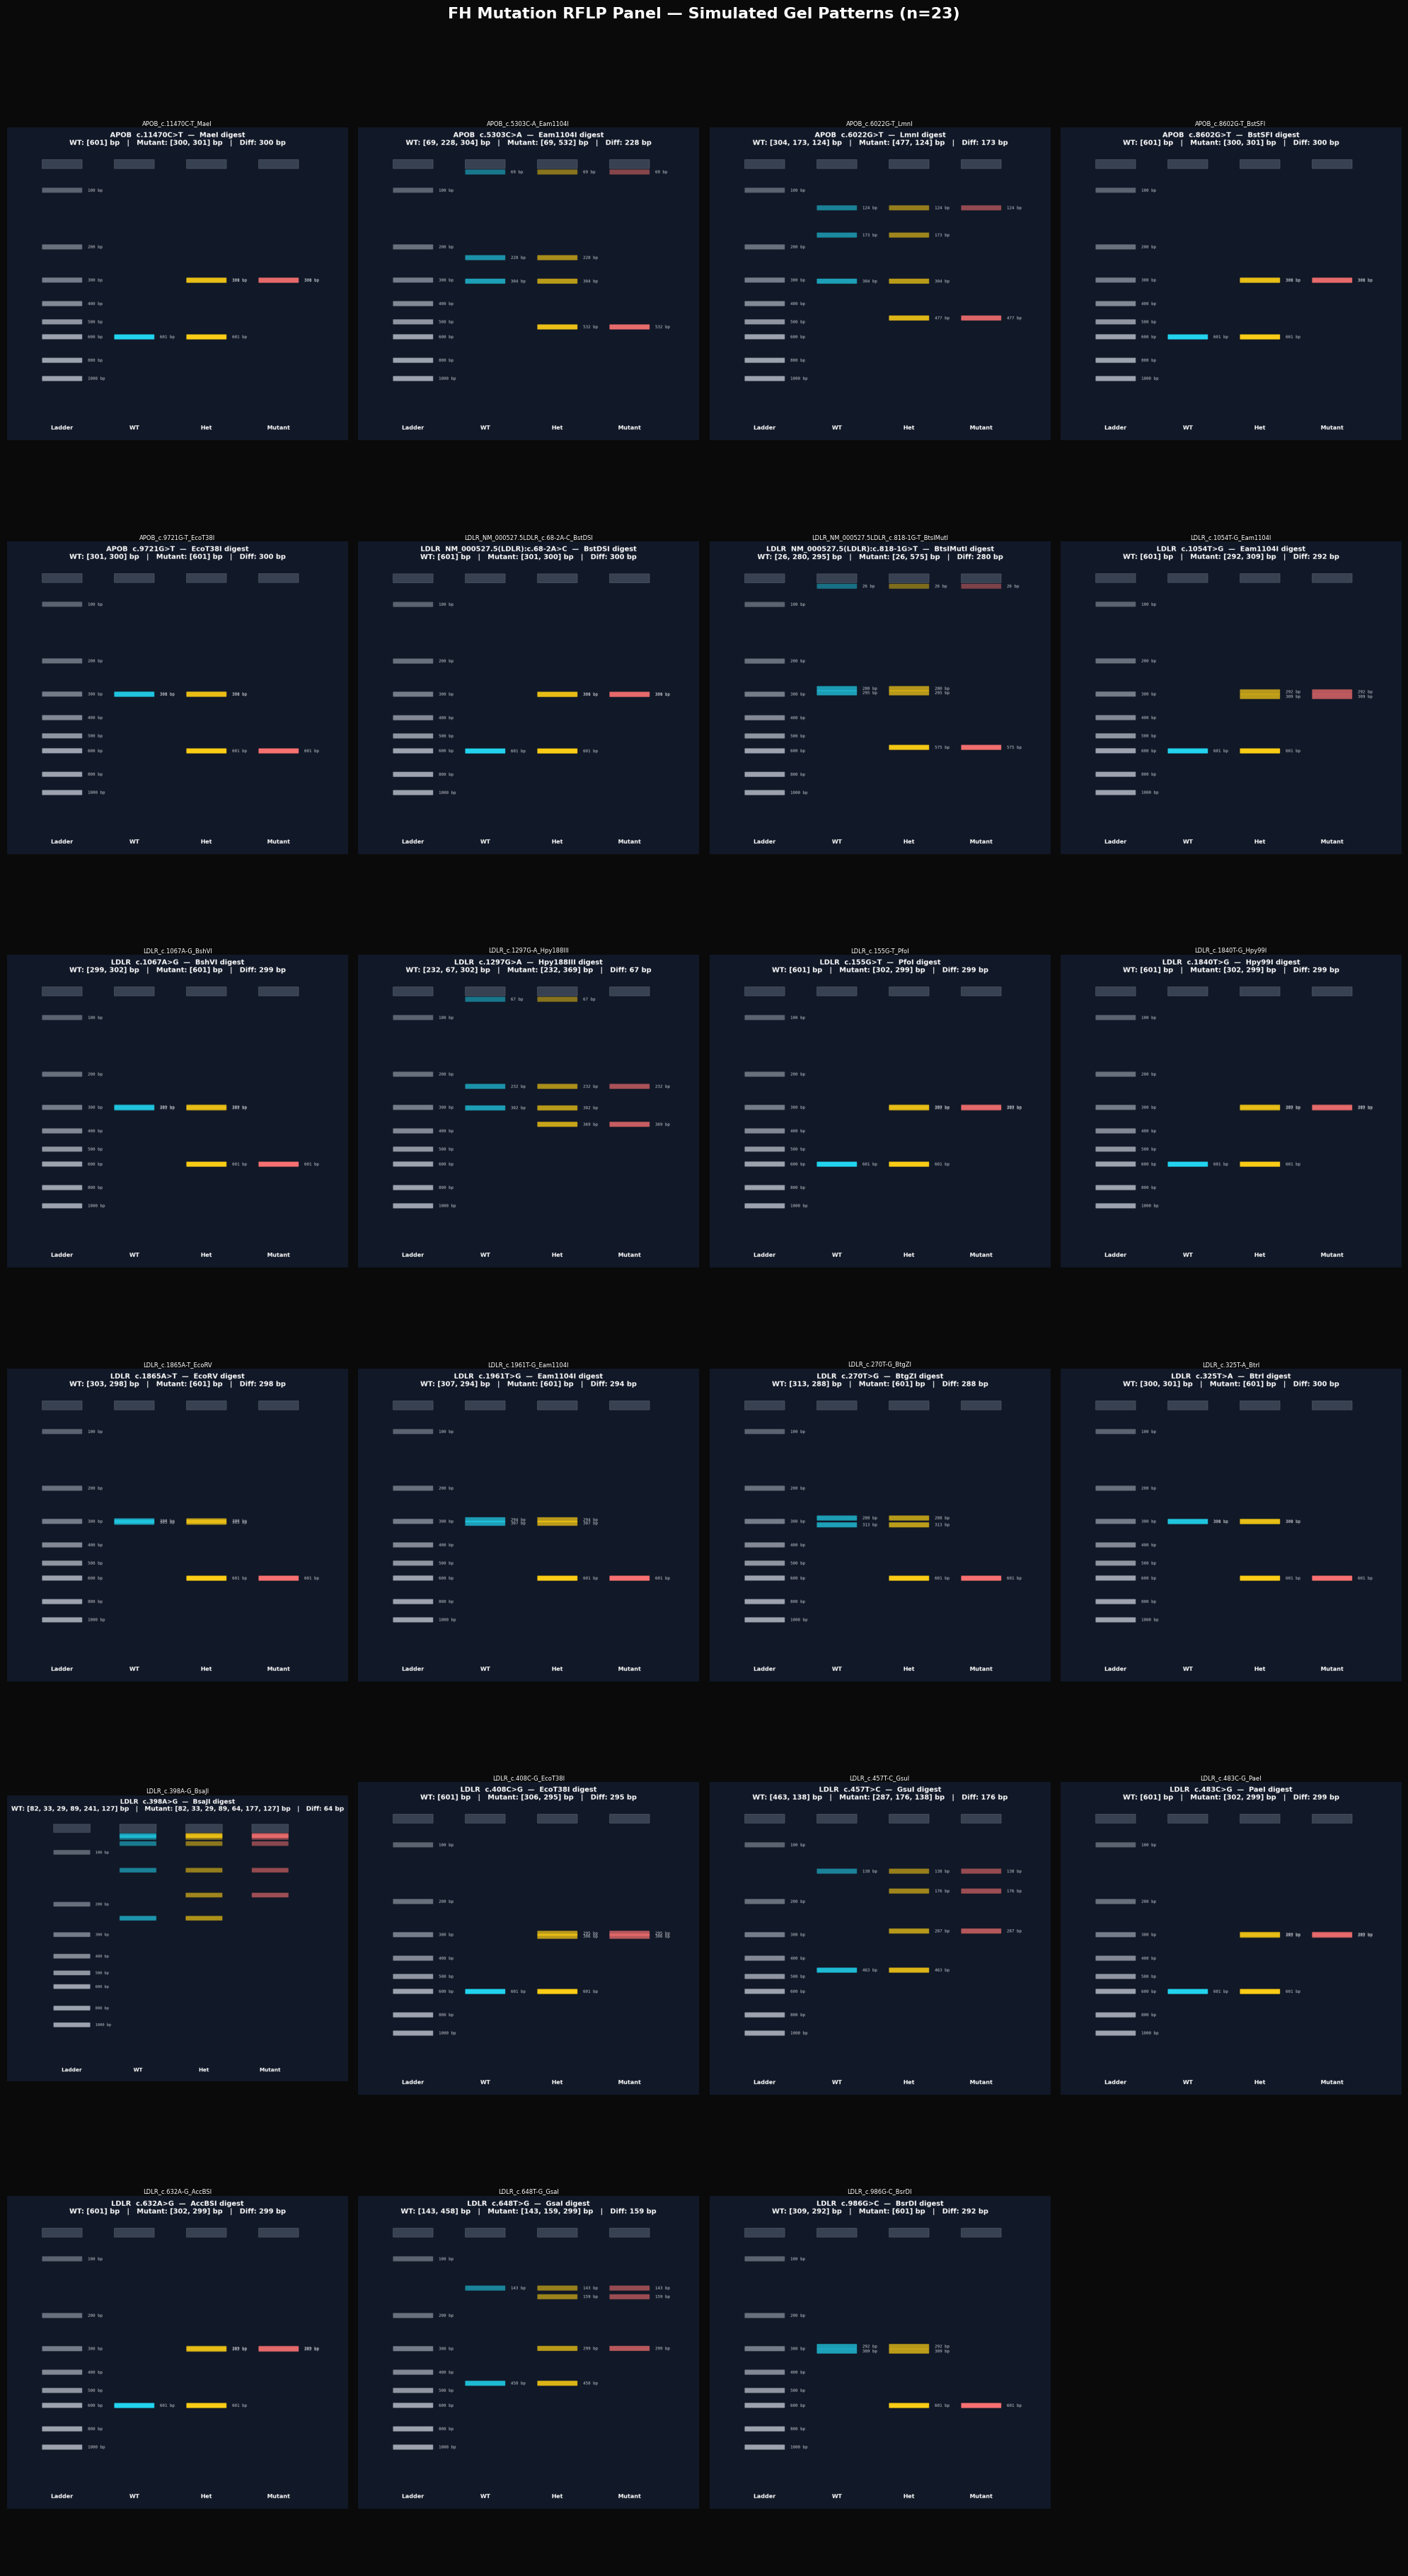

Saved: results/figures/MASTER_gel_panel.png
Phase 5 complete!


In [7]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Use the exact file list we just confirmed
files = sorted([
    os.path.join("results/figures", f)
    for f in os.listdir("results/figures")
    if f.endswith(".png") and f != "MASTER_gel_panel.png"
])

n_cols = 4
n_rows = math.ceil(len(files) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 5, n_rows * 6))
fig.patch.set_facecolor("#0a0a0a")
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(files):
        try:
            img = mpimg.imread(files[i])
            ax.imshow(img)
            # Add filename as subtitle
            name = os.path.basename(files[i]).replace(".png","")
            ax.set_title(name, color="white", fontsize=6, pad=3)
        except Exception as e:
            ax.set_title(f"Error: {e}", color="red", fontsize=6)
    ax.axis("off")

fig.suptitle(
    "FH Mutation RFLP Panel — Simulated Gel Patterns (n=23)",
    color="white", fontsize=16, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("results/figures/MASTER_gel_panel.png",
            dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: results/figures/MASTER_gel_panel.png")
print("Phase 5 complete!")